In [71]:
"""
Post-processing for evaluation data.
Goal 1: Normalize fallback options ("Other", "No information") to empty string.
"""
from pathlib import Path

import pandas as pd

# === CONSTANTS ===
INPUT_PATH = Path("df_text_by_report_conversation_evaluation.csv")

# Label column base names (human-annotated columns)
LABEL_KEYS = [
    "vic_grupo_social",
    "amenaza_quien",
    "captura_metodo",
    "captura_tipo",
    "cautiverio_trato",
    "desenlace",
    "desenlace_tipo",
    "perp_tipo1",
    "perp_tipo2",
    "proced_contacto1",
    "proced_contacto2",
    "proced_contactado",
    "Tribunal_tipo",
    "proced_sent_tipo",
    "soc_civil",
]

# Classification columns follow pattern: {key}_classification
CLASSIFICATION_SUFFIX = "_classification"

In [72]:
# === LOAD DATA ===
df_raw = pd.read_csv(INPUT_PATH, encoding="utf-8")

print(f"Loaded {len(df_raw)} rows from {INPUT_PATH}")

Loaded 2229 rows from df_text_by_report_conversation_evaluation.csv


In [73]:
# === FALLBACK VALUES (from config/taxonomy.json) ===
# Exact fallback options found in taxonomy:
#   - "Other"          : vic_grupo_social, amenaza_quien, proced_contacto1, proced_contacto2
#   - "Other(s)"       : proced_contactado
#   - "No information" : all fields except proced_contacto1 and soc_civil
#   - Verbose fallbacks that convey "unknown/can't identify":
#     - "The article mentions that THERE WAS NOT a response" (proced_contactado)
#     - "Perpetrator" (amenaza_quien) - too generic
#     - "Particulars (when you cannot identify...)" (perp_tipo1) - can't identify = unknown
#     - "Particulars (when belonging to an organized criminal group is not identifiable)" (perp_tipo2)
#   - Dimension mismatch (outcome disguised as method/treatment):
#     - "Disappearance" (captura_metodo) - describes outcome, not capture method
#     - "Disappeared" (cautiverio_trato) - describes outcome, not treatment
FALLBACK_VALUES = {
    "Other",
    "Other(s)",
    "No information",
    "The article mentions that THERE WAS NOT a response",
    "Perpetrator",
    "Particulars (when you cannot identify their affiliation to an organized criminal group)",
    "Particulars (when belonging to an organized criminal group is not identifiable)",
    "Disappearance",
    "Disappeared",
}

FALLBACK_VALUES_LOWER = {v.lower() for v in FALLBACK_VALUES}


def is_fallback(value) -> bool:
    """Check if a label value is a fallback category (empty, NaN, or in FALLBACK_VALUES)."""
    if pd.isna(value):
        return True
    value_str = str(value).strip()
    if not value_str:
        return True
    return value_str.lower() in FALLBACK_VALUES_LOWER

In [74]:
# === NORMALIZATION FUNCTION ===

def normalize_label(value) -> str:
    """Normalize fallback values to empty string, keep valid labels as-is."""
    if is_fallback(value):
        return ""
    return str(value).strip()

In [75]:
# === APPLY NORMALIZATION ===

# Build list of all columns to normalize (human + classification)
columns_to_normalize = []
for key in LABEL_KEYS:
    columns_to_normalize.append(key)  # human column
    columns_to_normalize.append(f"{key}{CLASSIFICATION_SUFFIX}")  # model column

# Apply normalization
df = df_raw.copy()
normalized_count = 0

for col in columns_to_normalize:
    if col not in df.columns:
        print(f"Warning: column '{col}' not found in dataframe")
        continue
    
    before_empty = (df[col].isna() | (df[col].astype(str).str.strip() == "")).sum()
    df[col] = df[col].apply(normalize_label)
    after_empty = (df[col] == "").sum()
    
    newly_normalized = after_empty - before_empty
    if newly_normalized > 0:
        print(f"{col}: {newly_normalized} fallback values normalized to ''")
        normalized_count += newly_normalized

print(f"\nTotal: {normalized_count} values normalized across all columns")

vic_grupo_social: 63 fallback values normalized to ''
vic_grupo_social_classification: 1 fallback values normalized to ''
amenaza_quien: 27 fallback values normalized to ''
amenaza_quien_classification: 258 fallback values normalized to ''
captura_metodo: 761 fallback values normalized to ''
captura_metodo_classification: 665 fallback values normalized to ''
cautiverio_trato: 26 fallback values normalized to ''
cautiverio_trato_classification: 44 fallback values normalized to ''
perp_tipo1: 218 fallback values normalized to ''
perp_tipo1_classification: 183 fallback values normalized to ''
perp_tipo2: 13 fallback values normalized to ''
perp_tipo2_classification: 123 fallback values normalized to ''
proced_contacto1: 73 fallback values normalized to ''
proced_contacto1_classification: 16 fallback values normalized to ''
proced_contacto2: 11 fallback values normalized to ''
proced_contacto2_classification: 2 fallback values normalized to ''
proced_contactado: 180 fallback values normali

In [76]:
"""
=============================================================================
STAGE 2: Merge Separated Labels
=============================================================================
Goal: Combine split columns (tipo1/tipo2) into single list-valued columns.

Separated label pairs found in taxonomy (config/taxonomy.json):
  - perp_tipo1 + perp_tipo2       → perp_tipo
  - proced_contacto1 + proced_contacto2 → proced_contacto

Both human and classification columns will be merged.
Output: df with new merged columns containing lists of non-empty values.
"""

# === SEPARATED LABEL PAIRS ===
# Format: (col1, col2, merged_name)
SEPARATED_LABEL_PAIRS = [
    ("perp_tipo1", "perp_tipo2", "perp_tipo"),
    ("proced_contacto1", "proced_contacto2", "proced_contacto"),
]

In [77]:
# === MERGE FUNCTION ===

def merge_label_columns(row, col1: str, col2: str) -> list:
    """Merge two label columns into a list of non-empty values."""
    values = []
    for col in [col1, col2]:
        val = row.get(col, "")
        if val and str(val).strip():
            values.append(str(val).strip())
    return values

In [78]:
# === APPLY MERGE ===

df_stage2 = df.copy()

for col1, col2, merged_name in SEPARATED_LABEL_PAIRS:
    # Merge human columns
    if col1 in df_stage2.columns and col2 in df_stage2.columns:
        df_stage2[merged_name] = df_stage2.apply(
            lambda row: merge_label_columns(row, col1, col2), axis=1
        )
        print(f"Merged human: {col1} + {col2} → {merged_name}")
    
    # Merge classification columns
    col1_cls = f"{col1}{CLASSIFICATION_SUFFIX}"
    col2_cls = f"{col2}{CLASSIFICATION_SUFFIX}"
    merged_cls = f"{merged_name}{CLASSIFICATION_SUFFIX}"
    
    if col1_cls in df_stage2.columns and col2_cls in df_stage2.columns:
        df_stage2[merged_cls] = df_stage2.apply(
            lambda row, c1=col1_cls, c2=col2_cls: merge_label_columns(row, c1, c2), axis=1
        )
        print(f"Merged classification: {col1_cls} + {col2_cls} → {merged_cls}")

print(f"\nStage 2 complete. df_stage2 shape: {df_stage2.shape}")

Merged human: perp_tipo1 + perp_tipo2 → perp_tipo
Merged classification: perp_tipo1_classification + perp_tipo2_classification → perp_tipo_classification
Merged human: proced_contacto1 + proced_contacto2 → proced_contacto
Merged classification: proced_contacto1_classification + proced_contacto2_classification → proced_contacto_classification

Stage 2 complete. df_stage2 shape: (2229, 56)


In [79]:
"""
=============================================================================
STAGE 3: Merge/Coarsen Label Values
=============================================================================
Goal: Address taxonomy design issues where values are not mutually exclusive,
      have hierarchical relationships, or near-duplicate meanings.

Target: Monophyletic categories that satisfy:
  - MUTUALLY EXCLUSIVE: Each option belongs to exactly one category
  - EXHAUSTIVE: All values have a category (no leftovers)
  - SINGLE DIMENSION: All categories defined by the same criterion
  - NO HIERARCHY MIXING: Parent and child not at same level
  - COMPARABLE: All categories are logically peers
  - NO CATCHALL: Positive criteria only, no residual categories as complement set of others

=============================================================================
PART A: PROBLEM TYPES
=============================================================================

1. HIERARCHICAL
   - Parent category exists alongside its children
   - LLM may pick specific child, human may pick generic parent (or vice versa)
   - Causes false negatives when both refer to same entity at different granularity
   - Example: "State agent" (parent) vs "Municipal police" (child)

2. SEMANTIC OVERLAP
   - Multiple labels describe the same concept with different wording
   - Different terms for essentially identical meaning
   - Example: "Kidnapping" vs "Plagio" vs "Levantón" (all = kidnapping)

3. NEAR-DUPLICATE
   - Labels that are the same entity with historical/variant names
   - Example: "District attorney's office" = "Office of the inspector general"

4. NON-EXCLUSIVE CATEGORIES
   - Categories that are not mutually exclusive by design
   - A single entity can legitimately belong to multiple categories
   - Example: A mayor is both "Civil servant" AND "People associated with politics"

=============================================================================
PART B: FIELD-BY-FIELD ANALYSIS
=============================================================================

-----------------------------------------------------------------------------
1. perp_tipo (merged from perp_tipo1 + perp_tipo2)
-----------------------------------------------------------------------------
   Options (after Stage 1 fallback removal):
     - "State agent (press article does not specify more information)"
     - "Municipal police"
     - "State police"
     - "Federal police"
     - "Army"
     - "Navy"
     - "Air Force"
     - "Ministerial police (...)"
     - "Relatives"
     - "Has or had a romantic relationship with victim"
     - "Organized crime (Z)"
     - "Organized crime (Caballeros Templarios)"
     - "Organized crime (Cartel de Sinaloa)"
     - "Organized crime (Cartel de Jalisco Nueva Generación)"
     - "Organized crime (Beltrán Leyva)"
     - "Organized crime (Cartel del Golfo)"
     - "Organized crime (Cartel de Juárez)"
     - "Organized crime (Los Rojos)"
     - "Organized crime (Los Ardillos)"
     - "Organized crime (La Familia Michoacana)"
     - "Organized crime (name is unspecified)"
   
   Problems:
     - HIERARCHICAL: "State agent" is parent of Municipal/State/Federal police, Army, Navy, Air Force, Ministerial police
     - HIERARCHICAL: "Organized crime (name is unspecified)" is parent of all specific cartels
   
   Suggested merge (affiliation-based, monophyletic):
     → State-affiliated (State agent, Municipal police, State police, Federal police, Army, Navy, Air Force, Ministerial police)
     → Criminal-organization-affiliated (all Organized crime variants)
     → Unaffiliated individual (Relatives, Has or had a romantic relationship with victim)

-----------------------------------------------------------------------------
2. captura_metodo
-----------------------------------------------------------------------------
   Options:
     - "Disappearance"
     - "Kidnapping"
     - "Scam"
     - "Plagio (kidnapping in a legal sense)"
     - "Detention/arrest"
     - "Military or political operation (raid)"
     - "Levantón (kidnapping but pejorative use towards the victim)"
   
   Problems:
     - SEMANTIC OVERLAP: "Kidnapping", "Plagio", "Levantón" all mean kidnapping
     - DIMENSION MISMATCH: "Disappearance" is an OUTCOME (person is gone), not a METHOD
       of capture. Violates monophyly - all other options describe HOW capture occurred.
     - SEMANTIC OVERLAP: "Detention/arrest" and "Military or political operation (raid)" overlap
       (a raid can result in detention; detention can be via raid)
   
   Suggested merge (method-based, monophyletic):
     → Kidnapping (Kidnapping, Plagio, Levantón)
     → Official detention (Detention/arrest, Military or political operation (raid))
     → Scam (as is)

-----------------------------------------------------------------------------
3. proced_contactado
-----------------------------------------------------------------------------
   Options (after Stage 1 fallback removal):
     - "Municipal police"
     - "State police"
     - "Federal police"
     - "Army"
     - "Navy"
     - "Air Force"
     - "Ministerial police (...)"
     - "District attorney's office"
     - "Office of the inspector general (previous title of district attorney's office)"
     - "Prosecutor"
     - "Commision on Human Rights"
     - "Governor"
     - "Mayor"
   
   Problems:
     - HIERARCHICAL: Police/military types (same as perp_tipo)
     - NEAR-DUPLICATE: "District attorney's office" = "Office of the inspector general"
     - SEMANTIC OVERLAP: "Prosecutor" may overlap with district attorney
   
   Suggested merge (institution-type-based, monophyletic):
     → Security forces (Municipal police, State police, Federal police, Army, Navy, Air Force, Ministerial police)
     → Prosecution/Justice bodies (District attorney's office, Office of the inspector general, Prosecutor)
     → Human rights bodies (Commission on Human Rights)
     → Elected officials (Governor, Mayor)

-----------------------------------------------------------------------------
4. desenlace
-----------------------------------------------------------------------------
   Options:
     - "Still disappeared"
     - "Liberated by captors"
     - "Liberated by authorities"
     - "Found dead"
     - "Escaped or was liberated through their own means"
     - "Found alive"
     - "Found, but does not specify if dead or alive"
   
   Problems:
     - HIERARCHICAL: "Found, but does not specify" is parent of "Found dead"/"Found alive"
     - SEMANTIC OVERLAP: Three liberation variants are related
   
   Suggested merge (outcome-based, monophyletic):
     → Still disappeared (as is)
     → Found (Found dead, Found alive, Found but does not specify if dead or alive, Liberated by captors, Liberated by authorities, Escaped or was liberated through their own means)

-----------------------------------------------------------------------------
5. captura_tipo
-----------------------------------------------------------------------------
   Options:
     - "Places related to the victim (house, workplace, private property)"
     - "Economic, social, industrial, agricultural and service centers"
     - "Authorities (government offices, military facilities)"
     - "Educational and medical facilities"
     - "Places for free expression, association and gatherings"
     - "Unoccupied or barren public spaces"
     - "Means and routes of transport and places of connection"
     - "International and protected spaces"
     - "Special centers and barracks for detention"
   
   Problems:
     - NON-EXCLUSIVE: Same location can belong to multiple categories
     - DIMENSION MIXING: Categories mix usage, ownership, and state
     - ANNOTATOR INTERPRETATION: LLM and Human may choose different categories for same location,
       both valid (e.g., "bus office in residential area" → service center OR victim-related place)
   
   Suggested merge (binary, reduce false negatives):
     → Places related to the victim (as is)
     → Public and institutional spaces (Economic centers, Authorities, Educational/medical facilities, Free expression places, Unoccupied spaces, Transport routes, International spaces, Detention centers)

-----------------------------------------------------------------------------
6. desenlace_tipo
-----------------------------------------------------------------------------
   Options:
     - "Places related to the victim (house, workplace, private property)"
     - "Economic, social, industrial, agricultural and service centers"
     - "Authorities (government offices, military facilities)"
     - "Educational and medical facilities"
     - "Places for free expression, association and gatherings"
     - "Unoccupied or barren public spaces"
     - "Means and routes of transport and places of connection"
     - "International and protected spaces"
     - "Centers and quarters for detention"
   
   Problems:
     - NON-EXCLUSIVE: Same location can belong to multiple categories
     - DIMENSION MIXING: Categories mix usage, ownership, and state
     - ANNOTATOR INTERPRETATION: LLM and Human may choose different categories for same location
   
   Suggested merge (binary, reduce false negatives):
     → Places related to the victim (as is)
     → Public and institutional spaces (Economic centers, Authorities, Educational/medical facilities, Free expression places, Unoccupied spaces, Transport routes, International spaces, Detention centers)

-----------------------------------------------------------------------------
7. vic_grupo_social
-----------------------------------------------------------------------------
   Options:
     - "Professionals (Entrepreneur, Engineer, Professor, Journalist, etc)"
     - "People that work in service industries (taxi driver, salesman, etc)"
     - "Civil servants (Police, mayor, public worker, etc)"
     - "Belonging to some sexual identity group (LGBTQ)"
     - "People associated with politics"
     - "Activists (political activist, human rights, etc)"
     - "Organized crime"
     - "Students"
     - "Land Worker"
   
   Problems:
     - NON-EXCLUSIVE: "Civil servants" ∩ "People associated with politics" (mayor is both)
     - NON-EXCLUSIVE: "Activists" ∩ "People associated with politics" (political activists)
     - FUNDAMENTAL DIMENSION MIXING (violates monophyly):
       * Occupation: Professionals, Service workers, Land Worker, Students
       * Role/Activity: Civil servants, Activists, Politically associated
       * Identity: LGBTQ
       * Affiliation: Organized crime
   
   Suggested merge (partial coarsening, cross-dimensional kept as-is):
     → Students (as is)
     → Civil servants (Civil servants, People associated with politics)
     → Professionals (Professionals, People that work in service industries, Land Worker)
     → Organized crime (as is)
     → Activists (as is)
     → LGBTQ (as is)
   
-----------------------------------------------------------------------------
8. proced_contacto (merged from proced_contacto1 + proced_contacto2)
-----------------------------------------------------------------------------
   Options:
     - "Relatives"
     - "Neighbors"
     - "Agents of the State (...)"
     - "Human rights organizations"
     - "Foreign government"
     - "Legal representative"
   
   Problems:
     → None identified. Categories appear mutually exclusive.
   
   Suggested merge:
     → No action needed

-----------------------------------------------------------------------------
9. amenaza_quien
-----------------------------------------------------------------------------
   Options (after Stage 1 fallback removal):
     - "Organized crime"
     - "Armed group"
     - "Relative"
     - "Neighbor"
     - "Someone known by the victim"
   
   Problems:
     - SEMANTIC OVERLAP: "Organized crime" and "Armed group" can overlap (cartels are armed groups)
     - NON-EXCLUSIVE: "Relative" ⊂ "Someone known by the victim" (a relative IS someone known)
     - DIMENSION MIXING: "Organized crime"/"Armed group" = organization type;
       "Relative"/"Neighbor"/"Someone known" = relationship to victim. Not monophyletic.
   
   Suggested merge (affiliation-based, monophyletic):
     → Organization (Organized crime, Armed group)
     → Known individual (Relative, Neighbor, Someone known by the victim)
   

-----------------------------------------------------------------------------
10. cautiverio_trato
-----------------------------------------------------------------------------
   Options:
     - "Strangulation"
     - "Torture"
     - "Disappeared"
     - "Witness of the torture of their relatives"
     - "Identity theft"
     - "Dismembered"
   
   Problems:
     - HIERARCHICAL: "Torture" is broad; "Strangulation", "Dismembered" could be forms of torture
     - SEMANTIC MISMATCH: "Disappeared" is an outcome, not a treatment during captivity
     - NON-EXCLUSIVE: Multiple treatments can apply to same victim (e.g., tortured AND dismembered)
   
   Suggested merge (treatment-type-based, monophyletic):
     → Physical violence (Torture, Strangulation, Dismembered)
     → Witness of the torture of their relatives (as is)
     → Identity theft (as is)
   

-----------------------------------------------------------------------------
11. Tribunal_tipo
-----------------------------------------------------------------------------
   Options:
     - "State"
     - "Federal"
     - "Military"
   
   Problems:
     → None identified. Categories are mutually exclusive jurisdictions.
   
   Suggested merge:
     → No action needed

-----------------------------------------------------------------------------
12. proced_sent_tipo
-----------------------------------------------------------------------------
   Options:
     - "Consecutive"
     - "Condemnatory"
     - "Absolving"
   
   Problems:
     - SEMANTIC MISMATCH: "Consecutive" describes how sentences are applied (sequentially),
       while "Condemnatory"/"Absolving" describe the verdict type.
       These are not the same dimension of classification.
   
   Suggested merge (verdict-type-based, monophyletic):
     → Condemnatory (Condemnatory, Consecutive)
     → Absolving (as is)
   


-----------------------------------------------------------------------------
13. soc_civil
-----------------------------------------------------------------------------
   Options:
     - "Yes (explain more in the final comments section)"
     - "No"
   
   Problems:
     → None identified. Simple binary field.
   
   Suggested merge:
     → No action needed

=============================================================================
SUMMARY: FIELDS REQUIRING ACTION vs NO ACTION
=============================================================================

REQUIRES COARSENING (10 fields):
  1. perp_tipo         → affiliation-based: State-affiliated, Criminal-organization-affiliated, Unaffiliated individual
  2. captura_metodo    → method-based: Kidnapping, Official detention, Scam
  3. proced_contactado → institution-type-based: Security forces, Prosecution/Justice bodies, Human rights bodies, Elected officials
  4. desenlace         → outcome-based: Still disappeared, Found
  5. captura_tipo      → binary: Places related to the victim, Public and institutional spaces
  6. desenlace_tipo    → binary: Places related to the victim, Public and institutional spaces
  7. vic_grupo_social  → partial: Students, Civil servants, Professionals, Organized crime, Activists (as is), LGBTQ (as is)
  9. amenaza_quien     → affiliation-based: Criminal/Armed organization, Known individual
 10. cautiverio_trato  → treatment-based: Physical violence, Psychological trauma, Identity theft
 12. proced_sent_tipo  → verdict-based: Condemnatory, Absolving

NO ACTION NEEDED (3 fields):
  8. proced_contacto   - Categories mutually exclusive
 11. Tribunal_tipo     - Categories mutually exclusive
 13. soc_civil         - Simple binary

STAGE 1 FALLBACK ADDITIONS REQUIRED:
  - "Disappearance" (from captura_metodo) - outcome, not method
  - "Disappeared" (from cautiverio_trato) - outcome, not treatment

=============================================================================
NEXT STEP: Implement coarsening mappings as code.
=============================================================================
"""
print("Stage 3 problematic separations documented. Awaiting coarsening decisions.")

Stage 3 problematic separations documented. Awaiting coarsening decisions.


In [80]:
# =============================================================================
# STAGE 3: CATEGORY COARSENING
# =============================================================================
# Apply category_merging from taxonomy.json to consolidate fine-grained labels
# into coarser, monophyletic categories.

import json

# Load category merging config
with open("config/taxonomy.json", "r", encoding="utf-8") as f:
    taxonomy = json.load(f)

CATEGORY_MERGING = taxonomy["category_merging"]
NO_COARSENING_FIELDS = set(taxonomy["no_coarsening_fields"])

def apply_coarsening(value: str, mapping: dict) -> str:
    """Map original value to coarsened category. Return as-is if not in mapping."""
    if pd.isna(value) or value == "":
        return value
    return mapping.get(value, value)

# Build column-to-mapping lookup
# Handle special cases:
#   - perp_tipo in config applies to perp_tipo1, perp_tipo2
#   - proced_contacto was merged from proced_contacto1 + proced_contacto2
COLUMN_MAPPING = {}

for field, mapping in CATEGORY_MERGING.items():
    if field == "perp_tipo":
        # Apply to both perp_tipo1 and perp_tipo2
        COLUMN_MAPPING["perp_tipo1"] = mapping
        COLUMN_MAPPING["perp_tipo2"] = mapping
    else:
        COLUMN_MAPPING[field] = mapping

# Apply coarsening
df_stage3 = df_stage2.copy()

coarsened_count = 0
for col_base, mapping in COLUMN_MAPPING.items():
    # Apply to human-annotated column
    if col_base in df_stage3.columns:
        df_stage3[col_base] = df_stage3[col_base].apply(
            lambda v, m=mapping: apply_coarsening(v, m)
        )
        coarsened_count += 1
    
    # Apply to classification column
    col_cls = f"{col_base}{CLASSIFICATION_SUFFIX}"
    if col_cls in df_stage3.columns:
        df_stage3[col_cls] = df_stage3[col_cls].apply(
            lambda v, m=mapping: apply_coarsening(v, m)
        )
        coarsened_count += 1

print(f"Stage 3 complete. Applied coarsening to {coarsened_count} columns.")
print(f"df_stage3 shape: {df_stage3.shape}")

Stage 3 complete. Applied coarsening to 22 columns.
df_stage3 shape: (2229, 56)


In [81]:
# =============================================================================
# STAGE 4: SELECT FINAL TURN PER VICTIM & MODEL
# =============================================================================

# Keep only the final per-victim turn using the same ordering (victim, index)
df_final = (
    df_stage3.sort_values(by=["victim", "index"])
    .groupby("victim", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

# Available models
print("Available models:")
print(df_final['model'].unique())

# Select model
model = 'hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4'
model_name = model.split('/')[-1]
df_model = df_final[df_final['model'] == model].reset_index(drop=True)

print(f"\nModel: {model_name}")
print(f"Shape: {df_model.shape}")
df_model.head()

Available models:
['hugging-quants/Meta-Llama-3.1-8B-Instruct-AWQ-INT4']

Model: Meta-Llama-3.1-8B-Instruct-AWQ-INT4
Shape: (575, 56)


,index,victim,text,text_len,text_words,vic_grupo_social,amenaza_quien,captura_metodo,captura_tipo,cautiverio_trato,...,proced_contacto1_match,proced_contacto2_match,proced_contactado_match,Tribunal_tipo_match,proced_sent_tipo_match,soc_civil_match,perp_tipo,perp_tipo_classification,proced_contacto,proced_contacto_classification
0,Coahuila_Abel M H_7,Coahuila_Abel M H,5/10/2019\r\nLiberan a Matataxistas para ejecu...,6300,892,Professionals,,,Public and institutional spaces,,...,1.0,0.0,0.0,0.0,0.0,0.0,[],[],[Relatives],"[Relatives, Relatives]"
1,Coahuila_Agustin Alberto N M_9,Coahuila_Agustin Alberto N M,Iban hacia el norte… - Proceso\r\nhttps://www....,14119,2284,Professionals,,Kidnapping,,,...,1.0,0.0,0.0,1.0,0.0,1.0,[Army],"[Organized crime (name is unspecified), Organi...",[Relatives],"[Relatives, Relatives]"
2,Coahuila_Agustin H G_4,Coahuila_Agustin H G,5/22/2019\r\nDesapariciones masivas... y silen...,16528,2542,Professionals,,,,,...,1.0,0.0,0.0,0.0,1.0,1.0,[],[],[Relatives],"[Relatives, Relatives]"
3,Coahuila_Alberto G H_3,Coahuila_Alberto G H,5/22/2019\r\nDesaparecen otros siete michoacan...,3733,544,Professionals,,,,,...,1.0,0.0,0.0,1.0,1.0,0.0,[],[],[Relatives],"[Relatives, Relatives]"
4,Coahuila_Antonio H H_2,Coahuila_Antonio H H,23/4/2019\r\nPiden apoyo para encontrar a meno...,5153,753,,,,,,...,1.0,1.0,0.0,1.0,1.0,0.0,[],[],[],[]


In [82]:
# =============================================================================
# STAGE 5: EVALUATION METRICS
# =============================================================================
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_PATH = Path("plots/merged_categories")
PLOT_PATH.mkdir(parents=True, exist_ok=True)

# Define the label mapping (human annotation -> machine classification)
# Updated for Stage 2 merged columns (perp_tipo, proced_contacto)
labelling_map = {
    'vic_grupo_social': 'vic_grupo_social_classification',
    'amenaza_quien': 'amenaza_quien_classification',
    'captura_metodo': 'captura_metodo_classification',
    'captura_tipo': 'captura_tipo_classification',
    'cautiverio_trato': 'cautiverio_trato_classification',
    'desenlace': 'desenlace_classification',
    'desenlace_tipo': 'desenlace_tipo_classification',
    'perp_tipo': 'perp_tipo_classification',  # merged from perp_tipo1 + perp_tipo2
    'proced_contacto': 'proced_contacto_classification',  # merged from proced_contacto1 + proced_contacto2
    'proced_contactado': 'proced_contactado_classification',
    'Tribunal_tipo': 'Tribunal_tipo_classification',
    'proced_sent_tipo': 'proced_sent_tipo_classification',
    'soc_civil': 'soc_civil_classification'
}

# Calculate metrics for each label
label_metrics = {}

for human_col, machine_col in labelling_map.items():
    # Get valid rows (both columns have values), if '', that row should not be eval
    mask = (
        df_model[human_col].notna() & 
        df_model[machine_col].notna() &
        (df_model[human_col].astype(str).str.strip() != '')
    )
    human_vals = df_model.loc[mask, human_col].astype(str)
    machine_vals = df_model.loc[mask, machine_col].astype(str)
    
    if len(human_vals) > 0:
        acc = accuracy_score(human_vals, machine_vals)
        f1 = f1_score(human_vals, machine_vals, average='macro', zero_division=0)
        kappa = cohen_kappa_score(human_vals, machine_vals)
        
        label_metrics[human_col] = {
            'Accuracy': acc,
            'F1 (macro)': f1,
            'Cohen Kappa': kappa
        }

# Convert to DataFrame for easy viewing
metrics_df = pd.DataFrame(label_metrics).T
metrics_df

,Accuracy,F1 (macro),Cohen Kappa
vic_grupo_social,0.459770,0.260653,0.321791
amenaza_quien,0.375000,0.181818,0.000000
captura_metodo,0.431953,0.301544,0.083442
captura_tipo,0.502058,0.343741,0.118932
cautiverio_trato,0.166667,0.142857,0.000000
desenlace,0.521628,0.414797,0.259598
desenlace_tipo,0.546392,0.279122,0.050501
perp_tipo,0.460870,0.013887,0.075975
proced_contacto,0.189565,0.032423,0.042198
proced_contactado,0.126984,0.019181,0.035658


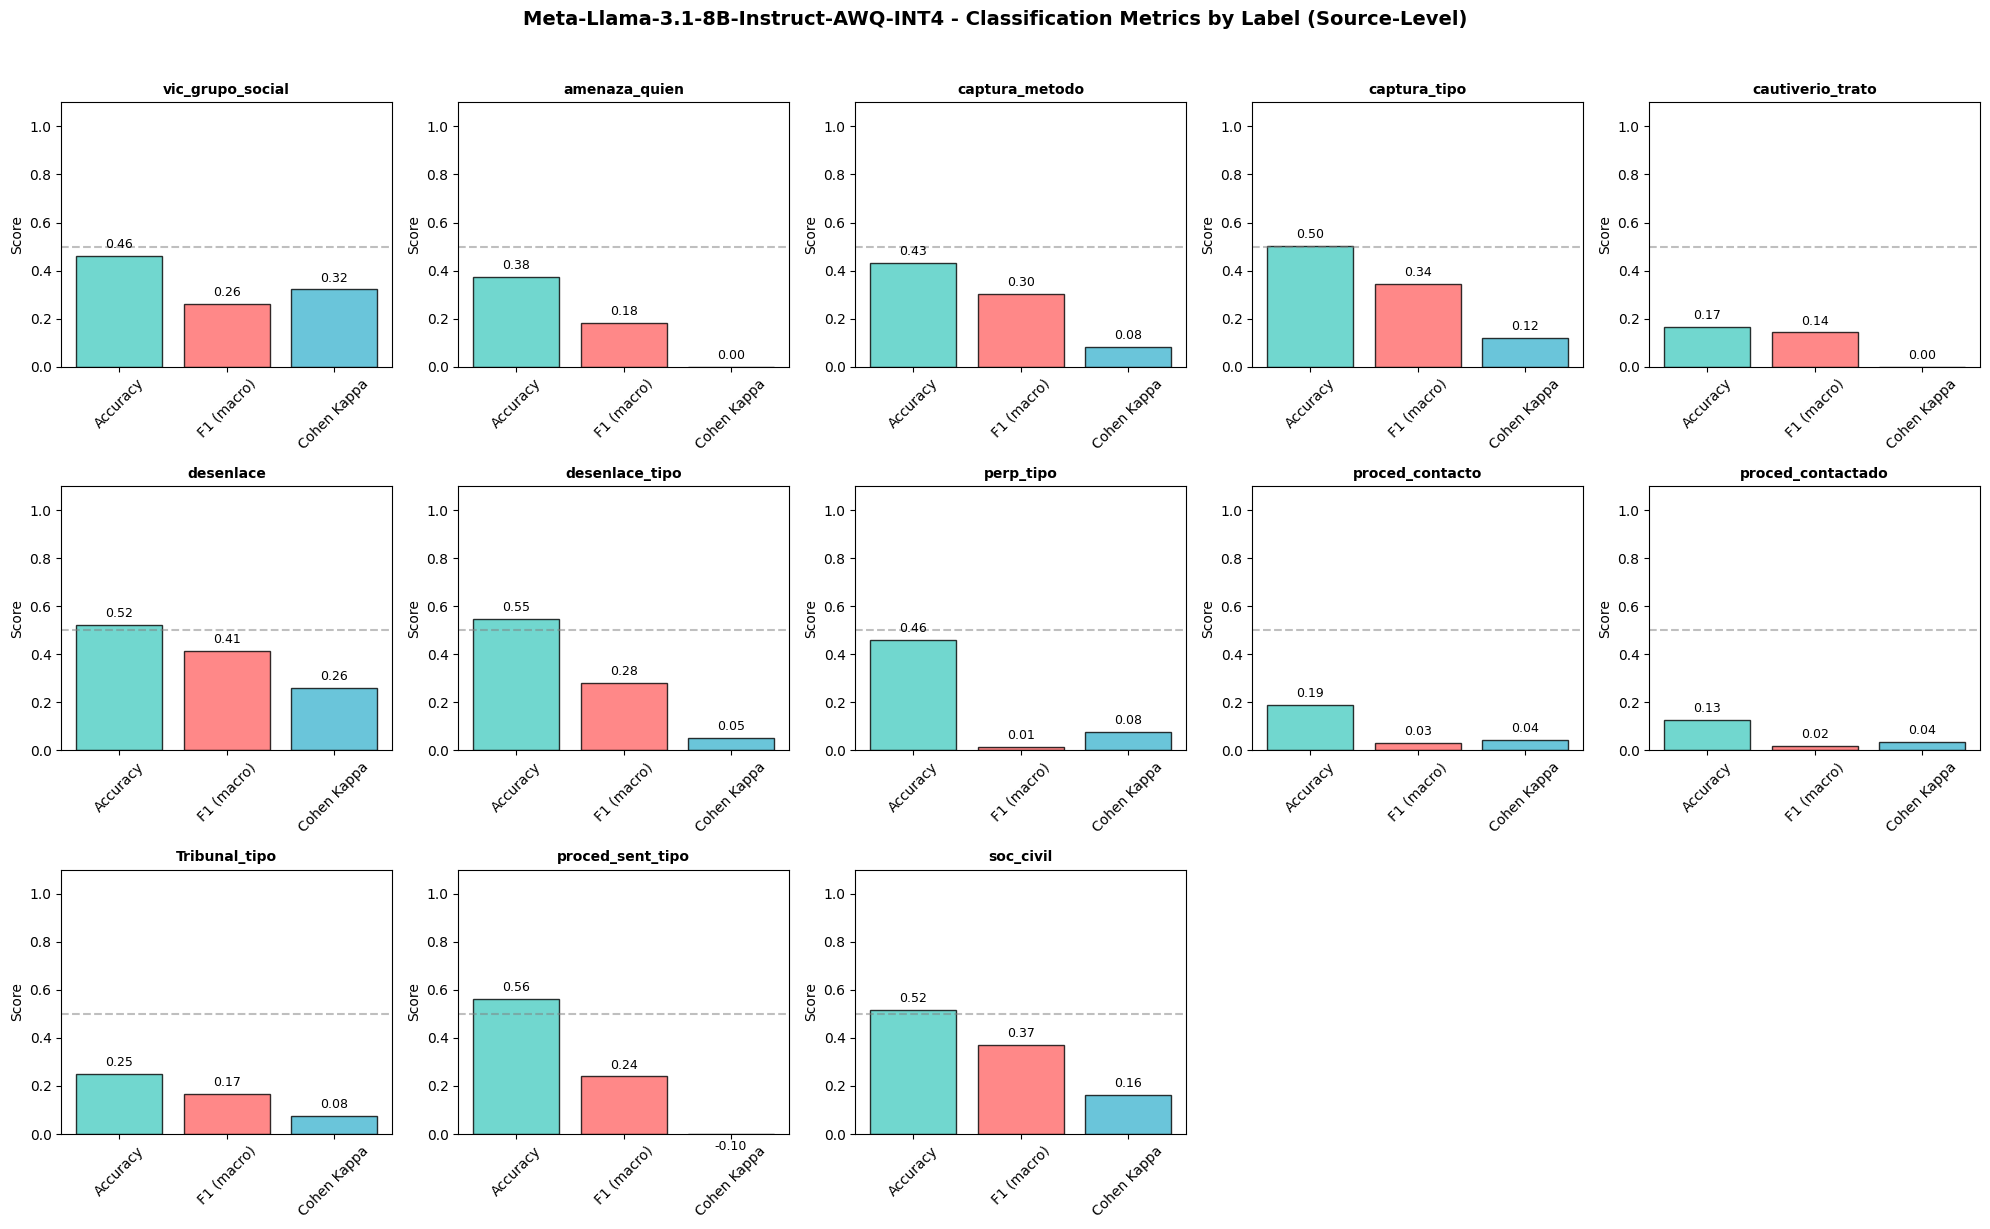

In [83]:
# Create matrix of plots - one subplot per label
n_labels = len(label_metrics)
n_cols = 5
n_rows = (n_labels + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

metric_names = ['Accuracy', 'F1 (macro)', 'Cohen Kappa']
colors = ['#4ecdc4', '#ff6b6b', '#45b7d1']

for idx, (label_name, metrics_dict) in enumerate(label_metrics.items()):
    ax = axes[idx]
    values = [metrics_dict[m] for m in metric_names]
    
    bars = ax.bar(metric_names, values, color=colors, edgecolor='black', alpha=0.8)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylim(0, 1.1)
    ax.set_title(label_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplots
for idx in range(len(label_metrics), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'{model_name} - Classification Metrics by Label (Source-Level)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_PATH / f'{model_name}_metrics_per_label_source.png', dpi=150, bbox_inches='tight')
plt.show()

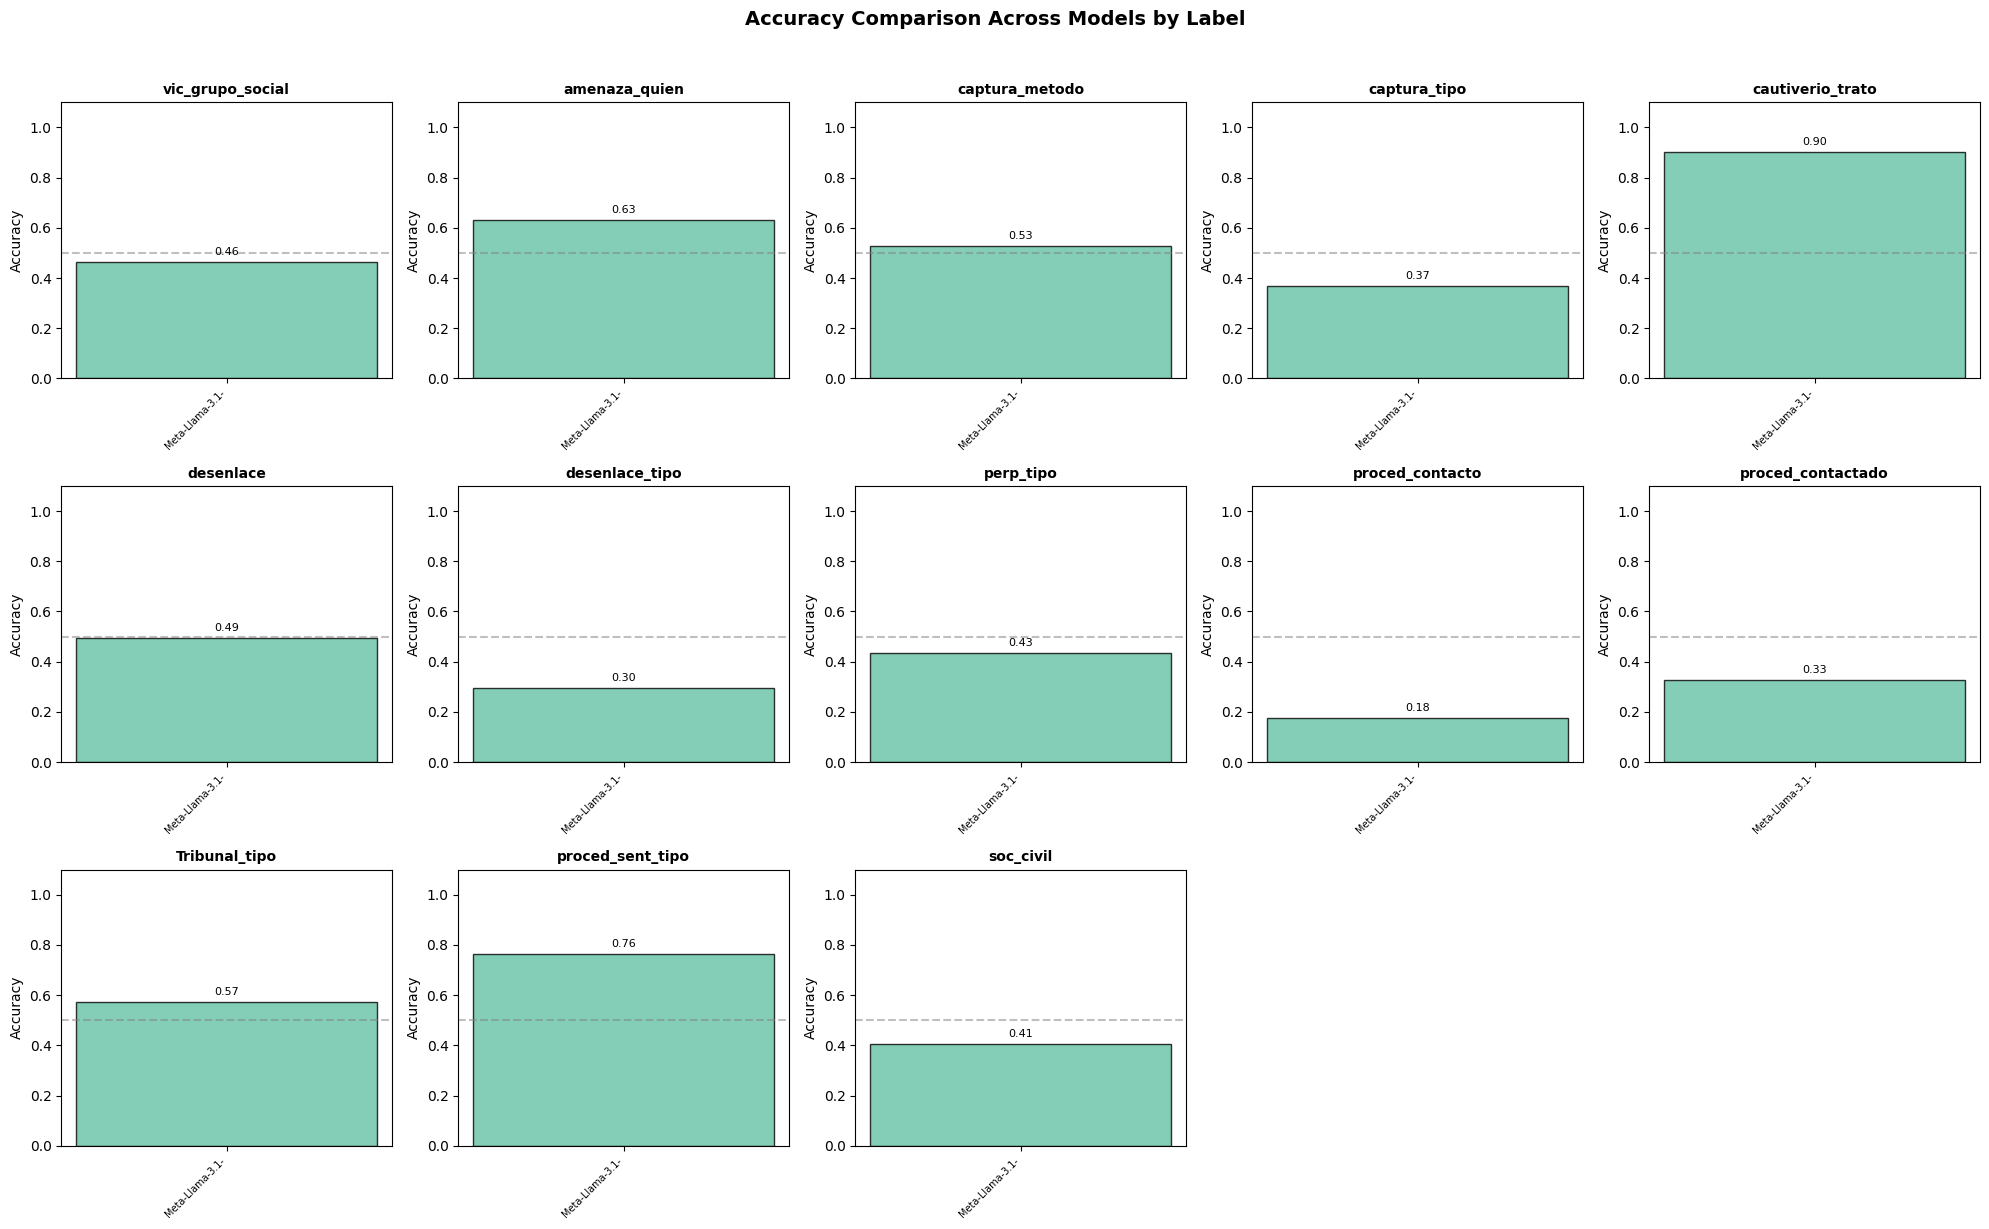

In [84]:
# Compare accuracy across models for each label
# Use df_stage3 (post-processed data)
models = df_stage3['model'].unique()
model_names = [m.split('/')[-1] for m in models]

# Calculate accuracy per model per label (same method as single-model plots)
acc_per_model = {}
for model_full, model_short in zip(models, model_names):
    df_m = df_stage3[df_stage3['model'] == model_full]
    acc_per_model[model_short] = {}
    
    for human_col, machine_col in labelling_map.items():
        mask = df_m[human_col].notna() & df_m[machine_col].notna()
        human_vals = df_m.loc[mask, human_col].fillna('').astype(str)
        machine_vals = df_m.loc[mask, machine_col].fillna('').astype(str)
        
        if len(human_vals) > 0:
            acc_per_model[model_short][human_col] = accuracy_score(human_vals, machine_vals)

label_names = list(labelling_map.keys())

# Plot: 15 subplots, each with bars for each model
n_labels = len(label_names)
n_cols = 5
n_rows = (n_labels + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

colors = plt.cm.Set2(range(len(model_names)))

for idx, label in enumerate(label_names):
    ax = axes[idx]
    accs = [acc_per_model[m][label] for m in model_names]
    
    bars = ax.bar(range(len(model_names)), accs, color=colors, edgecolor='black', alpha=0.8)
    
    for bar, val in zip(bars, accs):
        if not pd.isna(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_ylim(0, 1.1)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m[:15] for m in model_names], rotation=45, ha='right', fontsize=7)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Hide empty subplots
for idx in range(n_labels, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Accuracy Comparison Across Models by Label', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_PATH / 'accuracy_comparison_across_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [85]:
"""
=============================================================================
STAGE 5: Compare Post-Processed (opr_6) vs Raw (opr_5) Metrics
=============================================================================
1. Calculate raw metrics (without post-processing) using same filtering
2. Calculate difference: opr_6 (post-processed) - opr_5 (raw)
3. For merged labels (perp_tipo, proced_contacto), use average of split labels from opr_5
"""

# === STEP 1: Calculate RAW metrics (without post-processing) ===
# Load raw data and apply same filtering (last document per victim, same model)
df_raw_unprocessed = pd.read_csv(INPUT_PATH, encoding="utf-8")

# Filter: last document per victim
df_raw_filtered = (
    df_raw_unprocessed.sort_values(by=["victim", "index"])
    .groupby("victim", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

# Filter: same model as opr_6
df_raw_model = df_raw_filtered[df_raw_filtered['model'] == model].reset_index(drop=True)

print(f"Raw data (unprocessed): {len(df_raw_model)} rows")
print(f"Post-processed data: {len(df_model)} rows")

Raw data (unprocessed): 575 rows
Post-processed data: 575 rows


Raw metrics (opr_5 style, unprocessed):
                   Accuracy  F1 (macro)  Cohen Kappa
vic_grupo_social   0.442105    0.247620     0.338957
amenaza_quien      0.272727    0.183333     0.073684
captura_metodo     0.411576    0.239100     0.157643
captura_tipo       0.281915    0.201164     0.122316
cautiverio_trato   0.833333    0.454545     0.000000
desenlace          0.694340    0.416511     0.472501
desenlace_tipo     0.243590    0.149749     0.142538
perp_tipo1         0.315789    0.227397     0.232092
perp_tipo2         0.078947    0.021429    -0.008340
proced_contacto1   0.681452    0.122407     0.103341
proced_contacto2   0.574074    0.188596     0.117898
proced_contactado  0.067708    0.042766     0.034118
Tribunal_tipo      1.000000    1.000000          NaN
proced_sent_tipo   0.363636    0.266667     0.083333
soc_civil          0.609375    0.608089     0.219766
perp_tipo          0.197368    0.124413     0.111876
proced_contacto    0.627763    0.155502     0.110619


c:\Users\meier\OneDrive\Documents\messy_text\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\meier\OneDrive\Documents\messy_text\.venv\lib\site-packages\sklearn\metrics\_classification.py:897: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


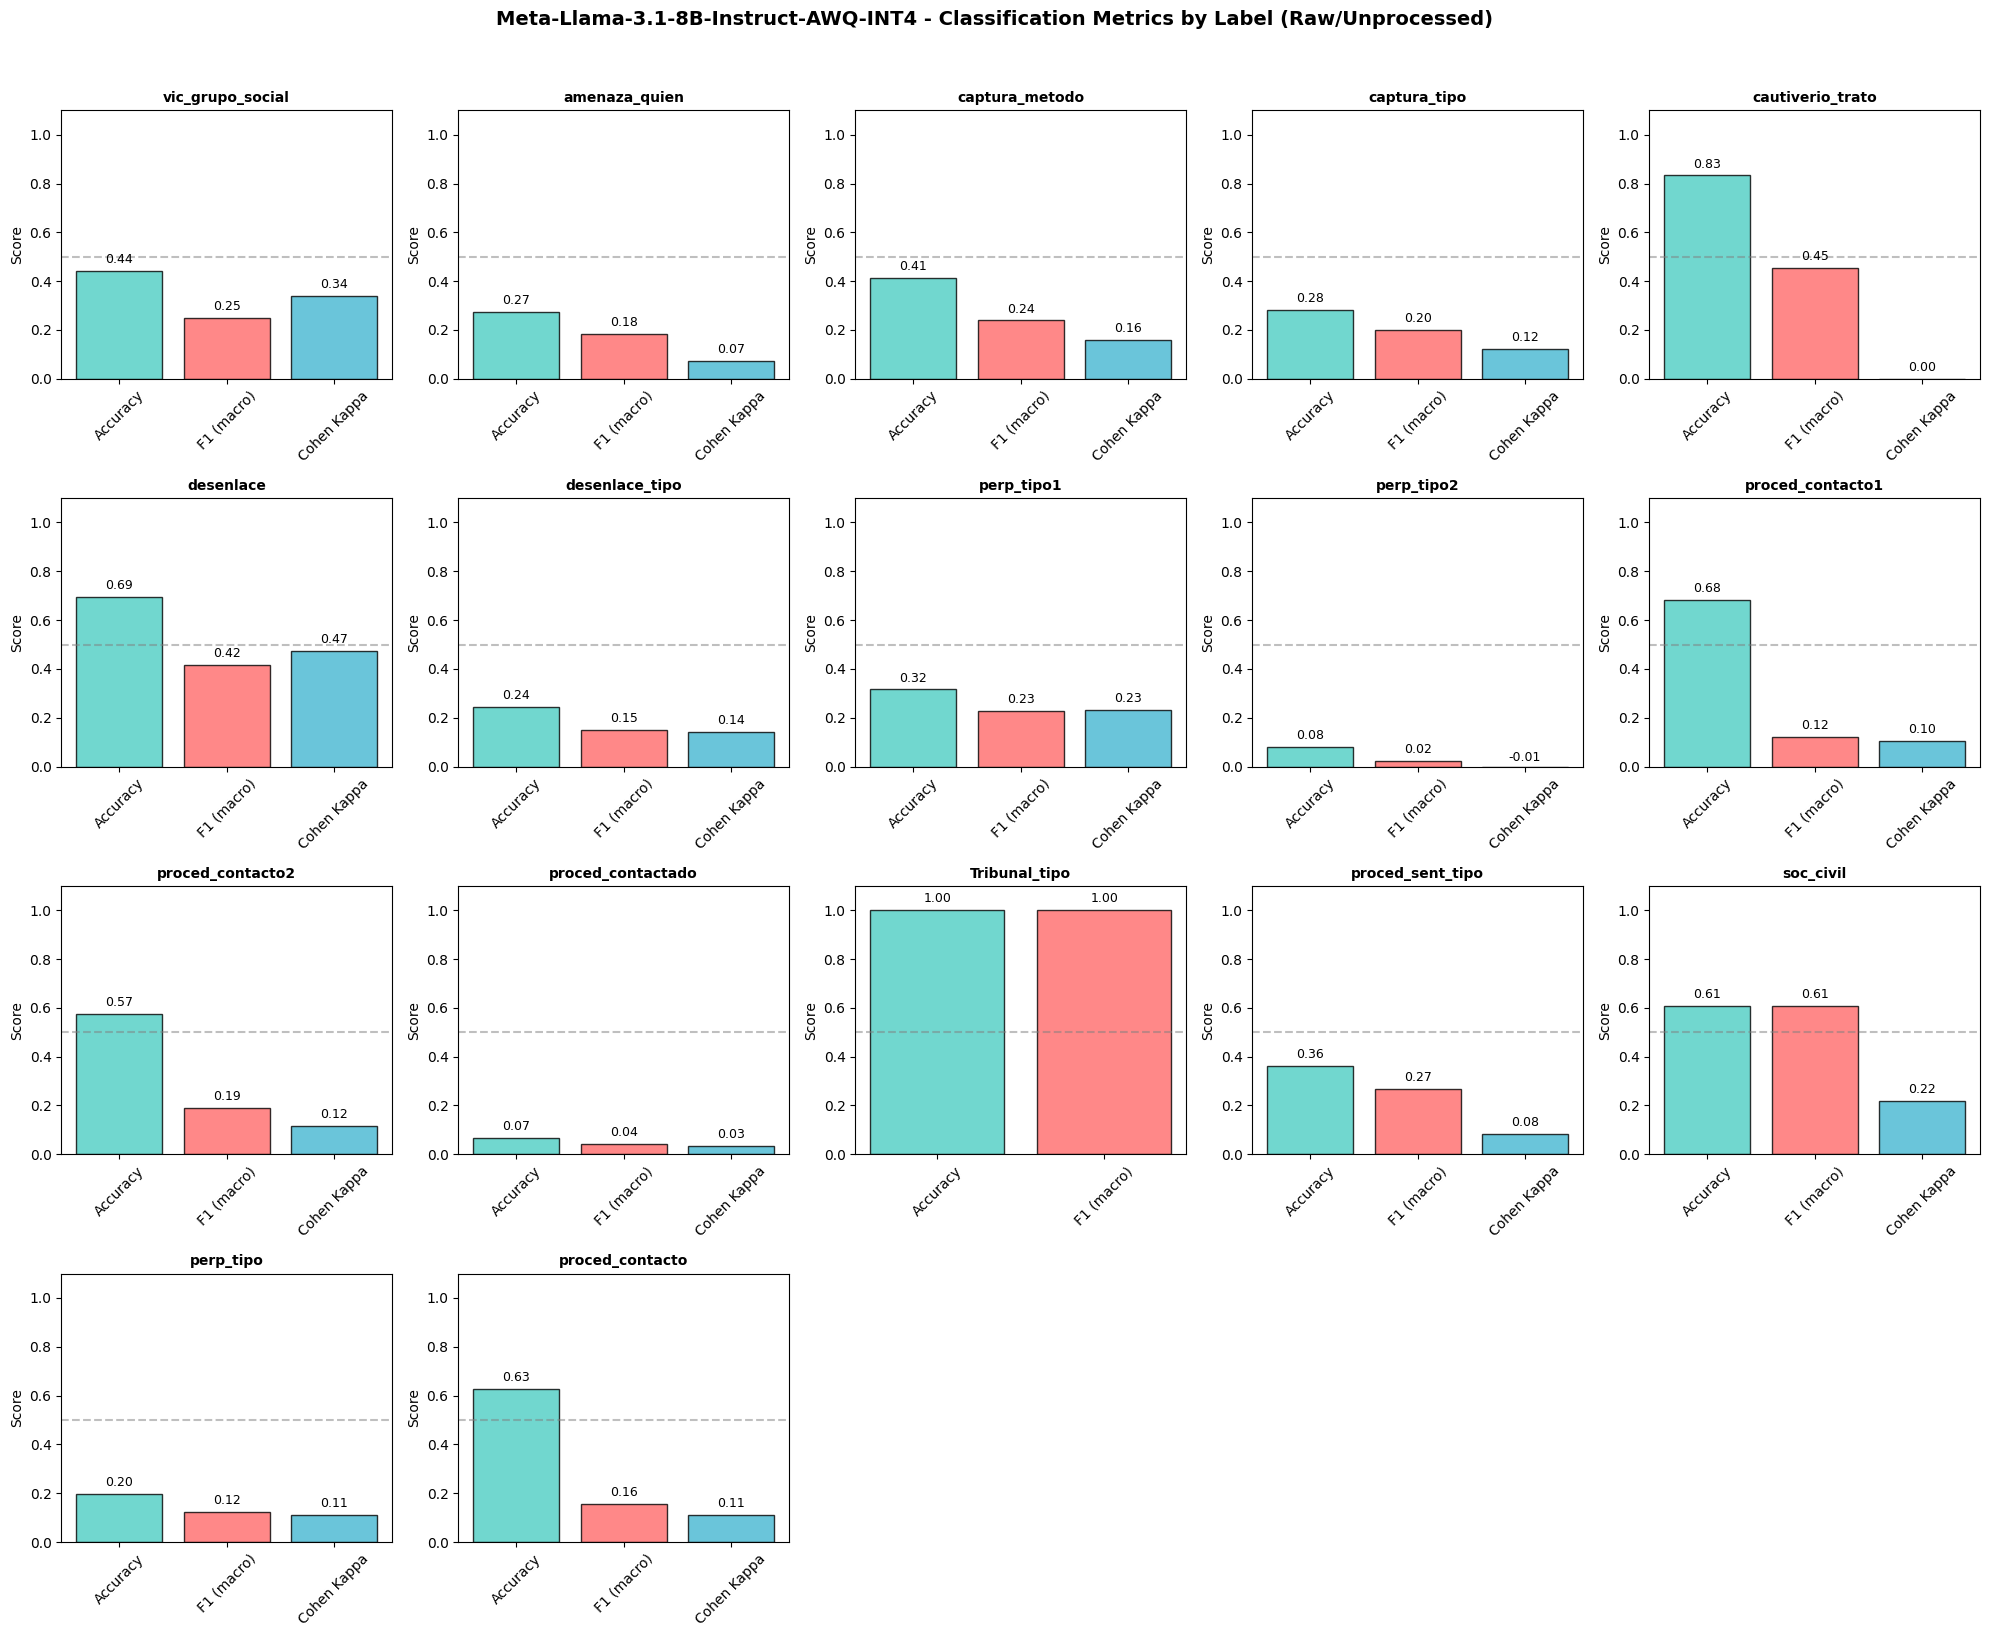

In [86]:
# === STEP 2: Calculate RAW metrics for each label (opr_5 style) ===
# Use original split labels: perp_tipo1, perp_tipo2, proced_contacto1, proced_contacto2

labelling_map_raw = {
    'vic_grupo_social': 'vic_grupo_social_classification',
    'amenaza_quien': 'amenaza_quien_classification',
    'captura_metodo': 'captura_metodo_classification',
    'captura_tipo': 'captura_tipo_classification',
    'cautiverio_trato': 'cautiverio_trato_classification',
    'desenlace': 'desenlace_classification',
    'desenlace_tipo': 'desenlace_tipo_classification',
    'perp_tipo1': 'perp_tipo1_classification',
    'perp_tipo2': 'perp_tipo2_classification',
    'proced_contacto1': 'proced_contacto1_classification',
    'proced_contacto2': 'proced_contacto2_classification',
    'proced_contactado': 'proced_contactado_classification',
    'Tribunal_tipo': 'Tribunal_tipo_classification',
    'proced_sent_tipo': 'proced_sent_tipo_classification',
    'soc_civil': 'soc_civil_classification'
}

# Calculate raw metrics
label_metrics_raw = {}

for human_col, machine_col in labelling_map_raw.items():
    if human_col not in df_raw_model.columns or machine_col not in df_raw_model.columns:
        continue
    
    mask = df_raw_model[human_col].notna() & df_raw_model[machine_col].notna()
    human_vals = df_raw_model.loc[mask, human_col].fillna('').astype(str)
    machine_vals = df_raw_model.loc[mask, machine_col].fillna('').astype(str)
    
    if len(human_vals) > 0:
        acc = accuracy_score(human_vals, machine_vals)
        f1 = f1_score(human_vals, machine_vals, average='macro', zero_division=0)
        kappa = cohen_kappa_score(human_vals, machine_vals)
        
        label_metrics_raw[human_col] = {
            'Accuracy': acc,
            'F1 (macro)': f1,
            'Cohen Kappa': kappa
        }

# Calculate average for merged labels
MERGED_TO_SPLIT = {
    'perp_tipo': ['perp_tipo1', 'perp_tipo2'],
    'proced_contacto': ['proced_contacto1', 'proced_contacto2'],
}

for merged_label, split_labels in MERGED_TO_SPLIT.items():
    split_metrics = [label_metrics_raw.get(sl) for sl in split_labels if sl in label_metrics_raw]
    if len(split_metrics) > 0:
        label_metrics_raw[merged_label] = {
            'Accuracy': sum(m['Accuracy'] for m in split_metrics) / len(split_metrics),
            'F1 (macro)': sum(m['F1 (macro)'] for m in split_metrics) / len(split_metrics),
            'Cohen Kappa': sum(m['Cohen Kappa'] for m in split_metrics) / len(split_metrics)
        }

# Display raw metrics
metrics_raw_df = pd.DataFrame(label_metrics_raw).T
print("Raw metrics (opr_5 style, unprocessed):")
print(metrics_raw_df)

# Plot raw metrics
n_labels_raw = len(label_metrics_raw)
n_cols = 5
n_rows = (n_labels_raw + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

metric_names = ['Accuracy', 'F1 (macro)', 'Cohen Kappa']
colors = ['#4ecdc4', '#ff6b6b', '#45b7d1']

for idx, (label_name, metrics_dict) in enumerate(label_metrics_raw.items()):
    ax = axes[idx]
    values = [metrics_dict[m] for m in metric_names]
    
    bars = ax.bar(metric_names, values, color=colors, edgecolor='black', alpha=0.8)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylim(0, 1.1)
    ax.set_title(label_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

for idx in range(len(label_metrics_raw), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'{model_name} - Classification Metrics by Label (Raw/Unprocessed)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_PATH / f'{model_name}_metrics_per_label_raw.png', dpi=150, bbox_inches='tight')
plt.show()

In [91]:
# === STEP 3: Calculate difference (opr_6 post-processed - opr_5 raw) ===
# Direct reference: label_metrics from STAGE 5, label_metrics_raw from STEP 2 (includes merged avg)

label_metrics_diff = {}

# All labels: direct subtraction (merged labels already averaged in STEP 2)
for label in label_metrics.keys():
    if label in label_metrics_raw:
        label_metrics_diff[label] = {
            'Accuracy': label_metrics[label]['Accuracy'] - label_metrics_raw[label]['Accuracy'],
            'F1 (macro)': label_metrics[label]['F1 (macro)'] - label_metrics_raw[label]['F1 (macro)'],
            'Cohen Kappa': label_metrics[label]['Cohen Kappa'] - label_metrics_raw[label]['Cohen Kappa']
        }

# Convert to DataFrame
metrics_diff_df = pd.DataFrame(label_metrics_diff).T
metrics_diff_df.columns = ['Δ Accuracy', 'Δ F1 (macro)', 'Δ Cohen Kappa']
print("Difference (Post-processed - Raw): Positive = post-processing improved performance")
metrics_diff_df

Difference (Post-processed - Raw): Positive = post-processing improved performance


,Δ Accuracy,Δ F1 (macro),Δ Cohen Kappa
vic_grupo_social,0.017665,0.013033,-0.017166
amenaza_quien,0.102273,-0.001515,-0.073684
captura_metodo,0.020377,0.062444,-0.074202
captura_tipo,0.220143,0.142577,-0.003384
cautiverio_trato,-0.666667,-0.311688,0.000000
desenlace,-0.172711,-0.001714,-0.212903
desenlace_tipo,0.302802,0.129373,-0.092037
perp_tipo,0.263501,-0.110526,-0.035901
proced_contacto,-0.438198,-0.123079,-0.068422
proced_contactado,0.059276,-0.023585,0.001540


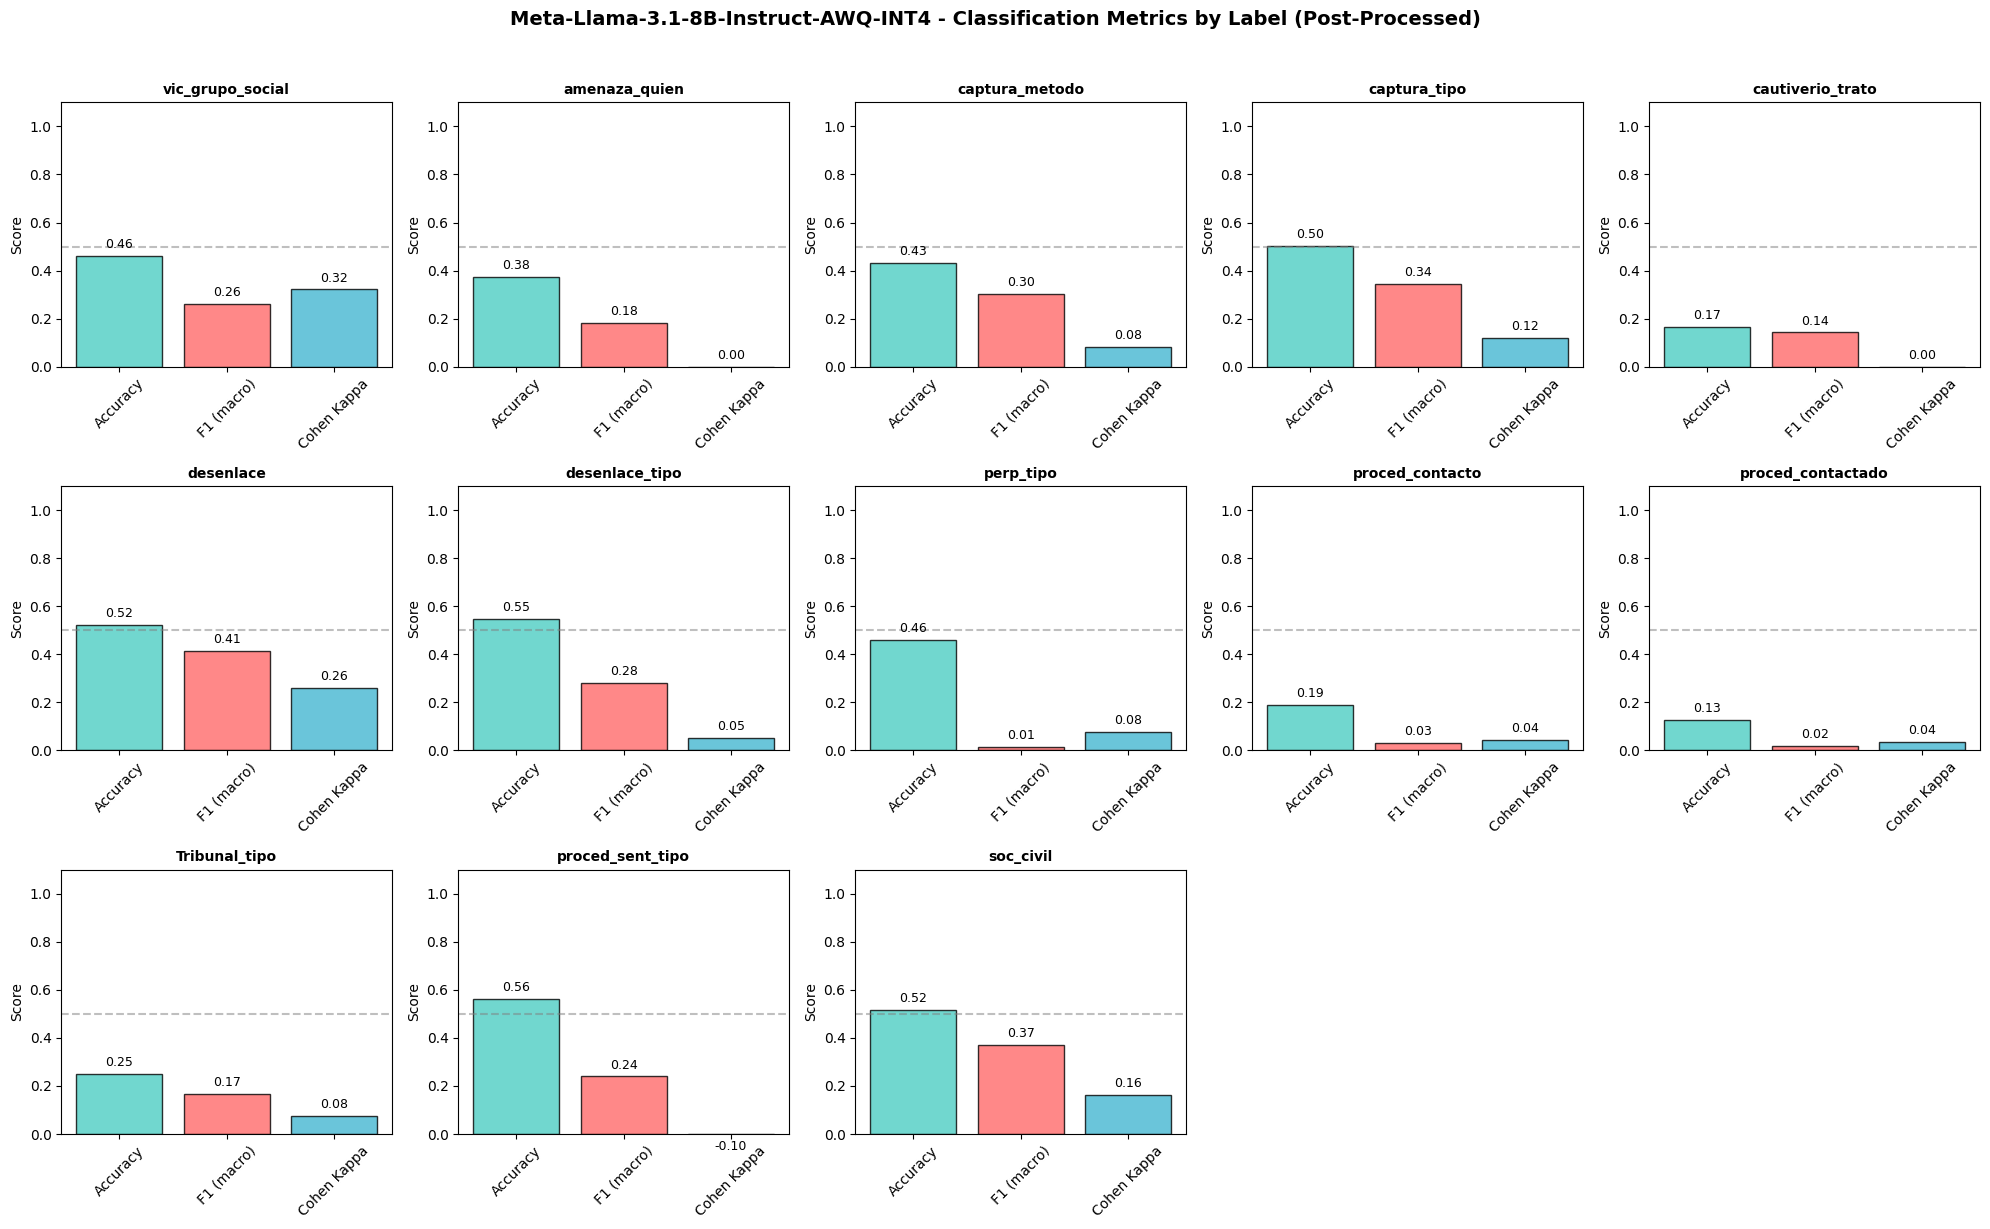

In [92]:
# === STEP 4: Plot post-processed metrics (opr_6 style) ===
n_labels = len(label_metrics)
n_cols = 5
n_rows = (n_labels + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

metric_names = ['Accuracy', 'F1 (macro)', 'Cohen Kappa']
colors = ['#4ecdc4', '#ff6b6b', '#45b7d1']

for idx, (label_name, metrics_dict) in enumerate(label_metrics.items()):
    ax = axes[idx]
    values = [metrics_dict[m] for m in metric_names]
    
    bars = ax.bar(metric_names, values, color=colors, edgecolor='black', alpha=0.8)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylim(0, 1.1)
    ax.set_title(label_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

for idx in range(len(label_metrics), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'{model_name} - Classification Metrics by Label (Post-Processed)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_PATH / f'{model_name}_metrics_per_label_postprocessed.png', dpi=150, bbox_inches='tight')
plt.show()

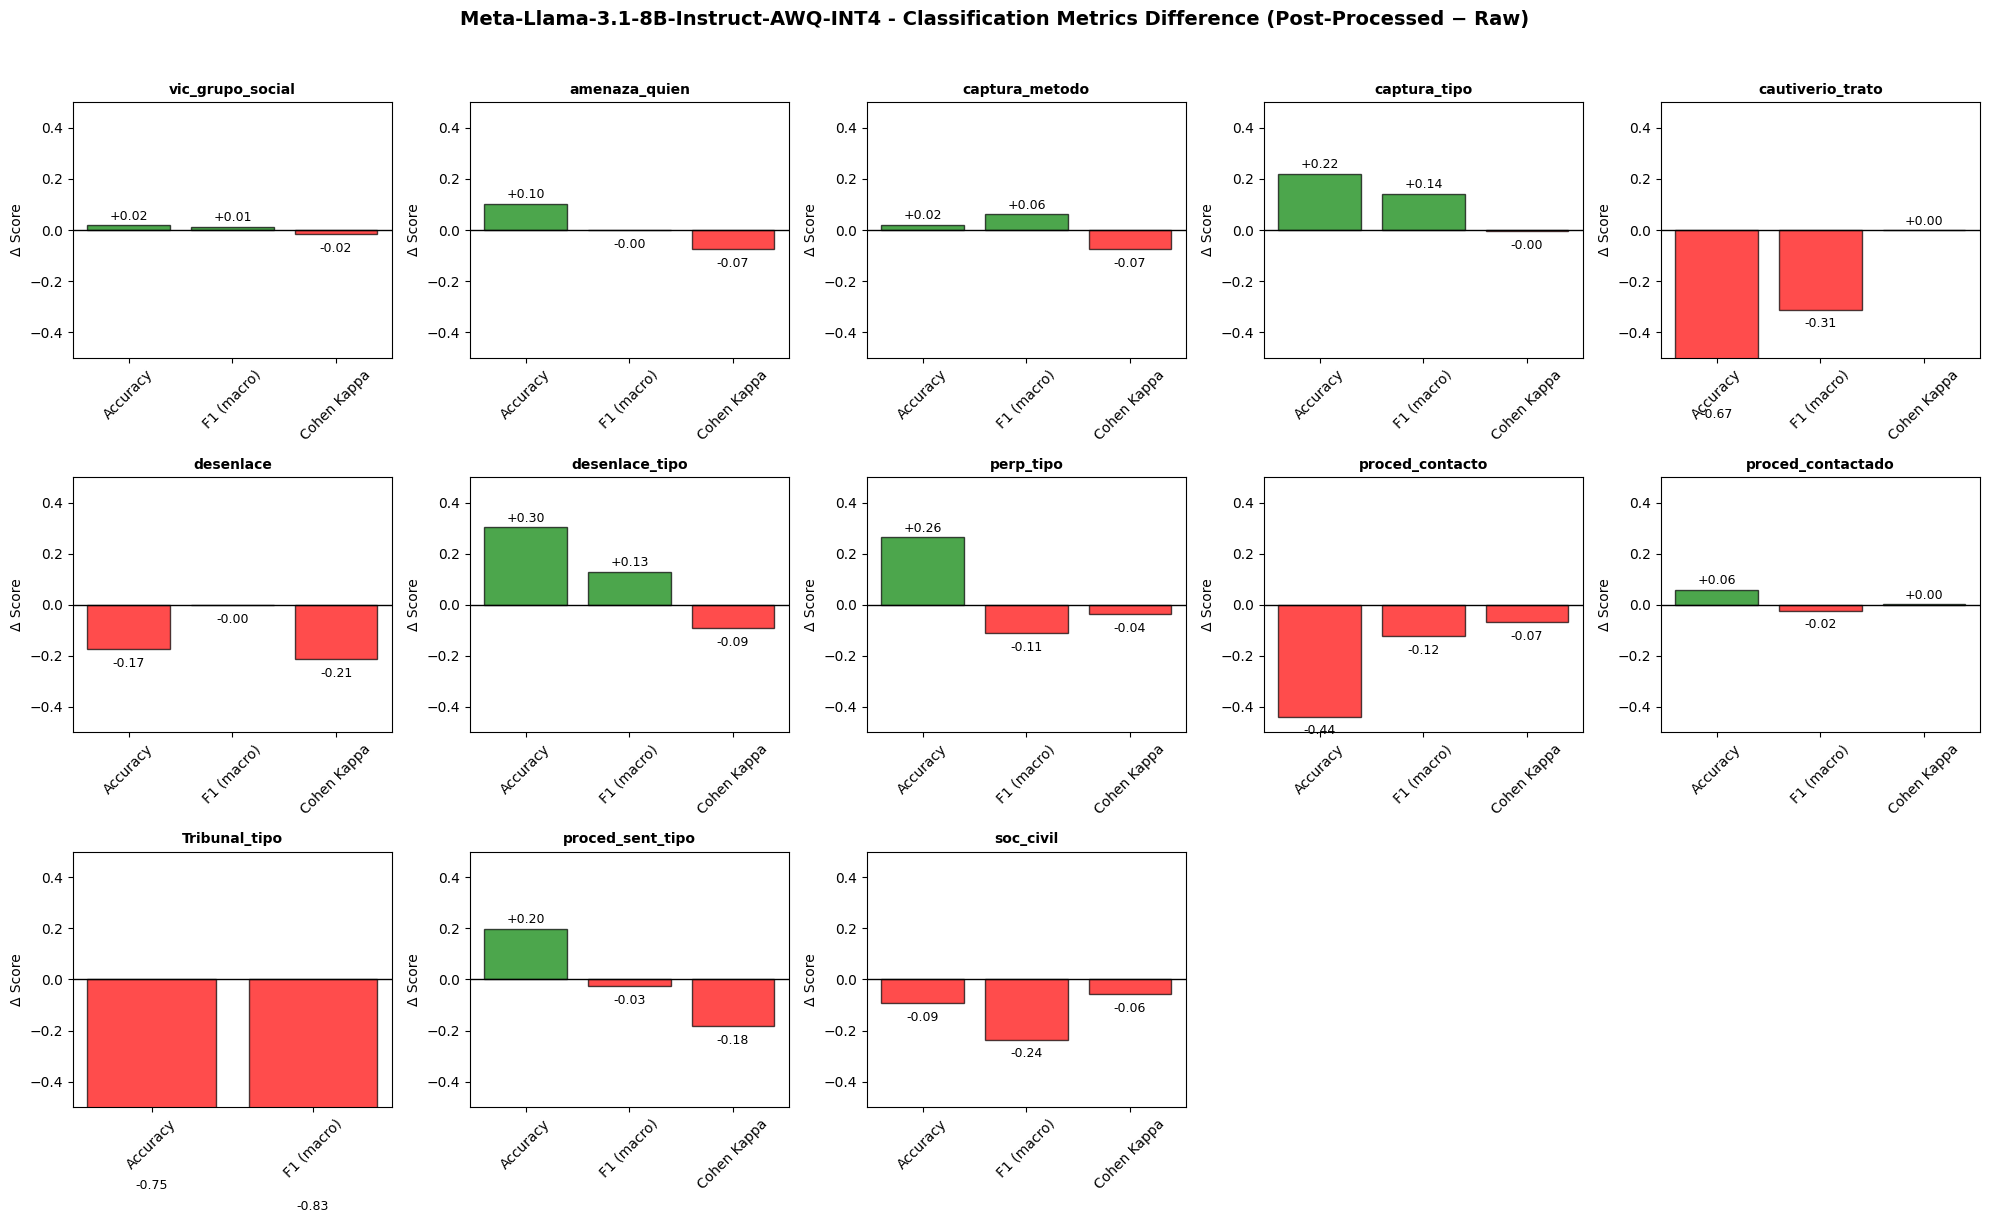

In [93]:
# === STEP 5: Plot metric differences (Post-processed - Raw) ===
n_labels = len(label_metrics_diff)
n_cols = 5
n_rows = (n_labels + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

metric_names = ['Accuracy', 'F1 (macro)', 'Cohen Kappa']

for idx, (label_name, metrics_dict) in enumerate(label_metrics_diff.items()):
    ax = axes[idx]
    values = [metrics_dict[m] for m in metric_names]
    
    # Color bars based on positive/negative
    bar_colors = ['green' if v >= 0 else 'red' for v in values]
    bars = ax.bar(metric_names, values, color=bar_colors, edgecolor='black', alpha=0.7)
    
    for bar, val in zip(bars, values):
        y_pos = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.03
        ax.text(bar.get_x() + bar.get_width()/2, y_pos, 
                f'{val:+.2f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)
    
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(label_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Δ Score')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.tick_params(axis='x', rotation=45)

for idx in range(len(label_metrics_diff), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'{model_name} - Classification Metrics Difference (Post-Processed − Raw)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_PATH / f'{model_name}_metrics_diff_postprocessed_vs_raw.png', dpi=150, bbox_inches='tight')
plt.show()